# Analysis of temporal analysis
This code was written by Sai and Danyka Byrnes

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np
from config import *

from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#### Answer the following questions based on the timeseries data:
1) Percentage of data missing between the start and end date.
  
2) The length between start and end datetime (hour) 

3) longest continous recored between the start and end date.  

In [5]:
# Pull and compile all data into one dataframe. Snippet written in part by Sai.
results = []

# Loop through each CSV
for file in os.listdir(water_quality_filepath):
    if not file.endswith(".csv"):
        continue

    file_path = os.path.join(water_quality_filepath, file)
    
    # Extract STREAM_ID from filename (remove .csv)
    stream_id = os.path.splitext(file)[0]

    df = pd.read_csv(file_path, low_memory=False) # mixed data types in df, maybe worth double checking

    if "DateTime" not in df.columns:
        continue

    # Convert DateTime
    df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
    df = df.sort_values("DateTime")

    station_result = {"STREAM_ID": stream_id}
    for solute in solutes:
        if solute in df.columns:

            df_solute = df[['DateTime', solute]].dropna(subset=solute)
            
            # Removing erroneous values 
            df_solute.loc[df_solute[solute] < 0, solute] = np.nan
            
            # Dropping NA then finding the max and min date.
            start = df_solute["DateTime"].min()
            end = df_solute["DateTime"].max()
            
            full_range = pd.date_range(start=start, end=end, freq="h")
            
            # Reindex to full hourly timeline to gapfill hours in the middle that may be empty.
            df_solute = df_solute.set_index("DateTime").reindex(full_range)
            series = df_solute[solute]
            
            # 1 Length between start and end
            length_hours = len(full_range)
            
            # 2 Percentage Missing
            missing_count = series.isna().sum() # this only counts NAs in the middle of timeseries
            percent_missing = (missing_count / length_hours) * 100

            # 3 Longest continuous record (non-missing streak)
            not_na = series.notna().astype(int)
            groups = (not_na.diff() != 0).cumsum()
            streak_lengths = not_na.groupby(groups).sum()
            longest_streak = streak_lengths.max() if len(streak_lengths) > 0 else 0

            # 4  total hours available
            actual_hours = series.notna().sum()

            # 5 Seasonal gaps. 
            monthly_pct = series.groupby(series.index.to_period("M")).apply(
                lambda x: x.isna().mean() * 100)
            median_by_month = monthly_pct.groupby(monthly_pct.index.month).median()

            # The choice of replacing nan with 100 is not arbitrary. The reason I picked 100 instead of NaN is because
            # seasonal I am plotting missingness against MAT to understand whether cold-climate stations have systematic winter gaps
            median_by_month = median_by_month.reindex(range(1, 13), fill_value=100)

            # populat the list with the new summary metrics
            station_result[f"{solute}_pct_missing"] = round(percent_missing, 2)
            station_result[f"{solute}_length_hr"] = length_hours
            station_result[f"{solute}_longest_hr"] = int(longest_streak)
            station_result[f"{solute}_actual_hr"] = int(actual_hours)

            for month_num in range(1, 13):
                col = f"{solute}_pct_missing_{month_num:02d}"
                if month_num in median_by_month.index:
                    station_result[col] = round(median_by_month[month_num], 2)
                else:
                    station_result[col] = np.nan

        else:
            station_result[f"{solute}_pct_missing"] = np.nan
            station_result[f"{solute}_length_hr"] = np.nan
            station_result[f"{solute}_longest_hr"] = np.nan
            station_result[f"{solute}_actual_hr"] = np.nan
            for month_num in range(1, 13):
                station_result[f"{solute}_pct_missing_{month_num:02d}"] = np.nan
            
    results.append(station_result)

# Convert to dataframe
temporal_summary = pd.DataFrame(results)
temporal_summary.head()

,STREAM_ID,SpC_uScm_pct_missing,SpC_uScm_length_hr,SpC_uScm_longest_hr,SpC_uScm_actual_hr,SpC_uScm_pct_missing_01,SpC_uScm_pct_missing_02,SpC_uScm_pct_missing_03,SpC_uScm_pct_missing_04,SpC_uScm_pct_missing_05,SpC_uScm_pct_missing_06,SpC_uScm_pct_missing_07,SpC_uScm_pct_missing_08,SpC_uScm_pct_missing_09,SpC_uScm_pct_missing_10,SpC_uScm_pct_missing_11,SpC_uScm_pct_missing_12,DO_mgL_pct_missing,DO_mgL_length_hr,DO_mgL_longest_hr,DO_mgL_actual_hr,DO_mgL_pct_missing_01,DO_mgL_pct_missing_02,DO_mgL_pct_missing_03,DO_mgL_pct_missing_04,DO_mgL_pct_missing_05,DO_mgL_pct_missing_06,DO_mgL_pct_missing_07,DO_mgL_pct_missing_08,DO_mgL_pct_missing_09,DO_mgL_pct_missing_10,DO_mgL_pct_missing_11,DO_mgL_pct_missing_12,Turb_FNU_pct_missing,Turb_FNU_length_hr,Turb_FNU_longest_hr,Turb_FNU_actual_hr,Turb_FNU_pct_missing_01,Turb_FNU_pct_missing_02,Turb_FNU_pct_missing_03,Turb_FNU_pct_missing_04,Turb_FNU_pct_missing_05,Turb_FNU_pct_missing_06,Turb_FNU_pct_missing_07,Turb_FNU_pct_missing_08,Turb_FNU_pct_missing_09,Turb_FNU_pct_missing_10,Turb_FNU_pct_missing_11,Turb_FNU_pct_missing_12,WTemp_C_pct_missing,WTemp_C_length_hr,WTemp_C_longest_hr,WTemp_C_actual_hr,WTemp_C_pct_missing_01,WTemp_C_pct_missing_02,WTemp_C_pct_missing_03,WTemp_C_pct_missing_04,WTemp_C_pct_missing_05,WTemp_C_pct_missing_06,WTemp_C_pct_missing_07,WTemp_C_pct_missing_08,WTemp_C_pct_missing_09,WTemp_C_pct_missing_10,WTemp_C_pct_missing_11,WTemp_C_pct_missing_12,NO3_mgNL_pct_missing,NO3_mgNL_length_hr,NO3_mgNL_longest_hr,NO3_mgNL_actual_hr,NO3_mgNL_pct_missing_01,NO3_mgNL_pct_missing_02,NO3_mgNL_pct_missing_03,NO3_mgNL_pct_missing_04,NO3_mgNL_pct_missing_05,NO3_mgNL_pct_missing_06,NO3_mgNL_pct_missing_07,NO3_mgNL_pct_missing_08,NO3_mgNL_pct_missing_09,NO3_mgNL_pct_missing_10,NO3_mgNL_pct_missing_11,NO3_mgNL_pct_missing_12,fDOM_QSU_pct_missing,fDOM_QSU_length_hr,fDOM_QSU_longest_hr,fDOM_QSU_actual_hr,fDOM_QSU_pct_missing_01,fDOM_QSU_pct_missing_02,fDOM_QSU_pct_missing_03,fDOM_QSU_pct_missing_04,fDOM_QSU_pct_missing_05,fDOM_QSU_pct_missing_06,fDOM_QSU_pct_missing_07,fDOM_QSU_pct_missing_08,fDOM_QSU_pct_missing_09,fDOM_QSU_pct_missing_10,fDOM_QSU_pct_missing_11,fDOM_QSU_pct_missing_12
0,STREAM-gauge-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.89,68288.0,10344.0,60850.0,0.00,0.0,0.00,0.07,0.0,0.0,0.13,1.55,0.0,0.07,0.14,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.22,68292.0,10346.0,67458.0,0.00,0.00,0.00,0.0,0.0,0.0,0.07,0.0,0.0,0.0,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,STREAM-gauge-100,1.87,8760.0,4702.0,8596.0,4.44,0.0,0.0,0.0,0.0,3.19,0.0,0.0,0.0,0.0,0.0,14.52,15.83,16776.0,4702.0,14121.0,4.44,0.0,0.27,0.00,0.0,1.6,0.00,50.00,50.0,46.44,23.06,7.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.28,13104.0,4702.0,12936.0,4.44,0.00,0.27,0.0,0.0,1.6,0.00,0.0,0.0,0.0,0.00,14.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,STREAM-gauge-1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,8785.0,8785.0,8785.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,STREAM-gauge-1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,8785.0,8785.0,8785.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,STREAM-gauge-1002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [8]:
# Reshaping temporal summary data from wide to long.

# Identify ID/metadata columns (keep these as-is)
id_cols = ['STREAM_ID']

# Reshape to long
rows = []
for solute in solutes:
    temp = temporal_summary[id_cols].copy()
    temp['parameter'] = solute
    temp['pct_missing'] = temporal_summary[f'{solute}_pct_missing']
    temp['length_hr'] = temporal_summary[f'{solute}_length_hr']
    temp['longest_hr'] = temporal_summary[f'{solute}_longest_hr']
    temp['actual_hr'] = temporal_summary[f'{solute}_actual_hr']

    # This parameter is the median percentage of the months across the record period that is missing data data. 
    # If the value is 100, it means that in at least one year, that month was in the timeseries, but it missing data
    # If the value is NaN, then the month never appeared in the timeseries.
    for month_num in range(1, 13):
        temp[f'pct_missing_{month_num:02d}'] = temporal_summary[f'{solute}_pct_missing_{month_num:02d}']
    rows.append(temp)

temporal_summary_long = (
    pd.concat(rows, ignore_index=True)
    .dropna(how='all', subset=['pct_missing', 'length_hr', 'longest_hr', 'actual_hr'])
)

temporal_summary_long.to_csv(OUTPUT_filepath+'temporal_statistics.csv', index=False)

In [9]:
# For now, just set 100 and NaNs both to 100 because I feel like these are corner cases. 
month_cols = [f'pct_missing_{m:02d}' for m in range(1, 13)]
temporal_summary_long[month_cols] = temporal_summary_long[month_cols].fillna(100)

temporal_summary_long.head()

,STREAM_ID,parameter,pct_missing,length_hr,longest_hr,actual_hr,pct_missing_01,pct_missing_02,pct_missing_03,pct_missing_04,pct_missing_05,pct_missing_06,pct_missing_07,pct_missing_08,pct_missing_09,pct_missing_10,pct_missing_11,pct_missing_12
1,STREAM-gauge-100,SpC_uScm,1.87,8760.0,4702.0,8596.0,4.44,0.00,0.00,0.00,0.00,3.19,0.00,0.00,0.00,0.00,0.00,14.52
12,STREAM-gauge-1010,SpC_uScm,14.02,3609.0,1674.0,3103.0,100.00,100.00,100.00,100.00,0.00,0.00,48.66,3.63,16.25,0.00,100.00,100.00
13,STREAM-gauge-1011,SpC_uScm,0.00,4472.0,4472.0,4472.0,100.00,100.00,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00
20,STREAM-gauge-1018,SpC_uScm,7.83,160001.0,2279.0,147480.0,0.87,0.36,0.40,0.28,0.13,0.28,0.34,1.28,0.56,0.27,0.42,0.27
22,STREAM-gauge-102,SpC_uScm,49.60,10541.0,2619.0,5313.0,100.00,100.00,68.82,33.47,70.97,0.00,0.00,0.00,60.83,47.92,32.85,60.98


In [14]:
# Creating a sepereate dataframe finding the percent missing data for each station, per year, and per month.
# This is similar processing to the previous block's code but it's at a year-month-scale for each station.
results = []

# Loop through each CSV
for file in os.listdir(water_quality_filepath):
    if not file.endswith(".csv"):
        continue

    file_path = os.path.join(water_quality_filepath, file)
    
    # Extract STREAM_ID from filename (remove .csv)
    stream_id = os.path.splitext(file)[0]

    df = pd.read_csv(file_path, low_memory=False) # mixed data types in df, maybe worth double checking

    if "DateTime" not in df.columns:
        continue

    # Convert DateTime
    df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
    df = df.sort_values("DateTime")

    for solute in solutes:
        if solute in df.columns:
            
            # Turning erroneous values as nan (assuming they were never measured)
            df_solute = df[['DateTime', solute]].dropna(subset=solute).copy()
            df_solute.loc[df_solute[solute] < 0, solute] = np.nan
            df_solute = df_solute.dropna(subset=[solute])
            
            # Dropping NA then finding the max and min date.
            start = df_solute["DateTime"].min()
            end = df_solute["DateTime"].max()
            
            full_range = pd.date_range(start=start, end=end, freq="h")
            
            # Reindex to full hourly timeline to gapfill hours in the middle that may be empty.
            df_solute = df_solute.set_index("DateTime").reindex(full_range)
            monthly_pct = df_solute[solute].groupby([df_solute.index.year, df_solute.index.month]).apply(
                lambda x: x.isna().mean() * 100
            )
            for (year, month), val in monthly_pct.items():
                results.append({
                    'STREAM_ID': stream_id,
                    'parameter': solute,
                    'year': int(year),
                    'month': int(month),
                    'pct_missing': round(val, 2)
                })

# Convert to dataframe
monthly_summary = pd.DataFrame(results)
monthly_summary.head()

,STREAM_ID,parameter,year,month,pct_missing
0,STREAM-gauge-1,DO_mgL,2014,12,0.0
1,STREAM-gauge-1,DO_mgL,2015,1,0.0
2,STREAM-gauge-1,DO_mgL,2015,2,0.0
3,STREAM-gauge-1,DO_mgL,2015,3,0.0
4,STREAM-gauge-1,DO_mgL,2015,4,0.0


In [10]:
# Creating another datafarme at a different resolution (one row per observed hourly reading)
results = []

# Loop through each CSV
for file in os.listdir(water_quality_filepath):
    if not file.endswith(".csv"):
        continue

    file_path = os.path.join(water_quality_filepath, file)
    stream_id = os.path.splitext(file)[0]

    df = pd.read_csv(file_path, low_memory=False)

    if "DateTime" not in df.columns:
        continue

    df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
    df = df.sort_values("DateTime")

    for solute in solutes:
        if solute in df.columns:
            df_solute = df[['DateTime', solute]].dropna(subset=[solute]).copy()
            df_solute.loc[df_solute[solute] < 0, solute] = np.nan
            df_solute = df_solute.dropna(subset=[solute])

            temp = pd.DataFrame({
                'STREAM_ID': stream_id,
                'solute': solute,
                'date': df_solute['DateTime'],
                'year': df_solute['DateTime'].dt.year,
                'month': df_solute['DateTime'].dt.month,
                'day': df_solute['DateTime'].dt.day,
                'hour': df_solute['DateTime'].dt.hour
            })
            results.append(temp)

hourly_summary = pd.concat(results, ignore_index=True)
hourly_summary.head()

,STREAM_ID,solute,date,year,month,day,hour
0,STREAM-gauge-1,DO_mgL,2014-12-17 06:00:00,2014,12,17,6
1,STREAM-gauge-1,DO_mgL,2014-12-17 07:00:00,2014,12,17,7
2,STREAM-gauge-1,DO_mgL,2014-12-17 08:00:00,2014,12,17,8
3,STREAM-gauge-1,DO_mgL,2014-12-17 09:00:00,2014,12,17,9
4,STREAM-gauge-1,DO_mgL,2014-12-17 10:00:00,2014,12,17,10


In [16]:
# Processing metadata, isolating specific parameters
md_wide = pd.read_csv(metadata_filepath+"metadata.csv", dtype = {'sourceID': str})
print(f"Full dataset size: {md_wide.shape[0]}")

for solute in solutes:
    md_wide[solute] = md_wide['WQ_parameters'].str.contains(solute)

# Removing the stations without data
md_wide = md_wide[md_wide[solutes].any(axis=1)]
print(f"Filtered dataset size: {md_wide.shape[0]}")

Full dataset size: 4268
Filtered dataset size: 4242


## Temporal Gaps (Where are the gaps over time?)

### Annual number of stations and seasonal cycles

In [18]:
# For a given solute, on each (year, month, day), how many unique stations reported at least once.
daily_occurrence = (
    hourly_summary
    .groupby(['solute', 'year', 'month', 'day'])['STREAM_ID']
    .nunique()
    .reset_index(name='n_stations')
)

daily_occurrence['DateTime'] = pd.to_datetime(
    daily_occurrence[['year', 'month', 'day']]
)

daily_occurrence['DateTime'] = pd.to_datetime(datetime_components_dict)
daily_occurrence.head()

,solute,year,month,day,n_stations,DateTime
0,DO_mgL,1989,10,10,1,1989-10-10
1,DO_mgL,1989,10,11,1,1989-10-11
2,DO_mgL,1989,10,12,1,1989-10-12
3,DO_mgL,1989,10,13,1,1989-10-13
4,DO_mgL,1989,10,14,1,1989-10-14


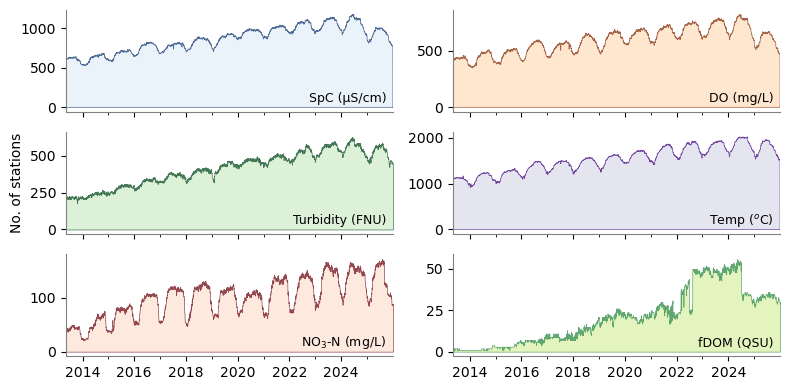

In [58]:
import matplotlib.dates as mdates

fig, axes_ij = plt.subplots(3, 2, figsize=(8, 4), sharex=True)
axes = axes_ij.flat
for i, solute in enumerate(solutes):
    solute_data = daily_occurrence[daily_occurrence['solute'] == solute]
    
    axes[i].fill_between(solute_data['DateTime'], solute_data['n_stations'],
                         color=PARAM_COLORS[solute]['fill'], alpha=0.7,
                         edgecolor=PARAM_COLORS[solute]['edge'], linewidth=0.5)
    if i == 2:
        axes[i].set_ylabel('No. of stations')
    else:
        axes[i].set_ylabel('')
        
    #axes[i].set_ylim(0, 1500)
    axes[i].set_xlim(solute_data['DateTime'].min(), solute_data['DateTime'].max())
    
    axes[i].text(0.98, 0.1, solute_pretty[solute], transform=axes[i].transAxes,
                 ha='right', fontsize=9)
    
    axes[i].spines['top'].set(visible=False)
    axes[i].spines['right'].set(visible=False)
    axes[i].spines['bottom'].set(visible=True, color='grey')
    axes[i].spines['left'].set(visible=True, color='grey')
    axes[i].xaxis.set_minor_locator(mdates.YearLocator(1))

fig.tight_layout()
plt.savefig(f'../OUTPUT/temporal_patterns/parameter_no_of_stations_year.png', dpi=600, bbox_inches='tight')

## Seasonal Gaps

### Where are the seasonal gaps?

In [62]:
temporal_summary_long.head(3)

,STREAM_ID,parameter,pct_missing,length_hr,longest_hr,actual_hr,pct_missing_01,pct_missing_02,pct_missing_03,pct_missing_04,pct_missing_05,pct_missing_06,pct_missing_07,pct_missing_08,pct_missing_09,pct_missing_10,pct_missing_11,pct_missing_12
1,STREAM-gauge-100,SpC_uScm,1.87,8760.0,4702.0,8596.0,4.44,0.0,0.0,0.0,0.0,3.19,0.00,0.00,0.00,0.0,0.0,14.52
12,STREAM-gauge-1010,SpC_uScm,14.02,3609.0,1674.0,3103.0,100.00,100.0,100.0,100.0,0.0,0.00,48.66,3.63,16.25,0.0,100.0,100.00
13,STREAM-gauge-1011,SpC_uScm,0.00,4472.0,4472.0,4472.0,100.00,100.0,100.0,100.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,100.00


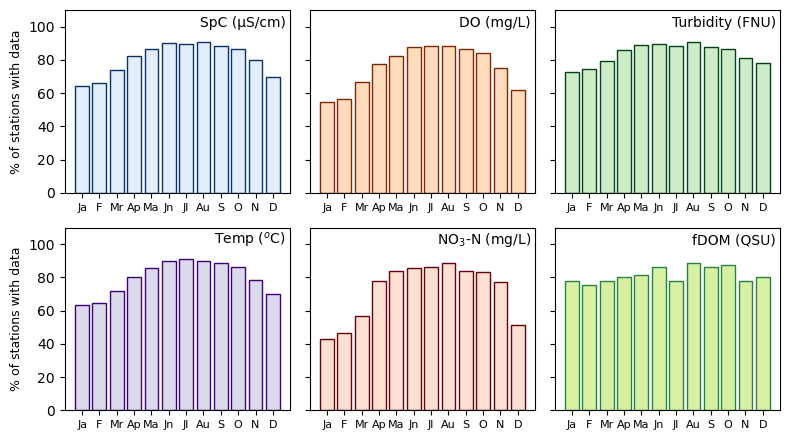

In [80]:
# What is the frequency of stations with no data, per month. 
# Using the median (across years) percent of missing data per month for each individual station.
month_cols = [f'pct_missing_{m:02d}' for m in range(1, 13)]
month_labels = ['Ja','F','Mr','Ap','Ma','Jn','Jl','Au','S','O','N','D']

fig, axes_ij = plt.subplots(2, 3, figsize=(8, 4.5), sharey=True)
axes = axes_ij.flat
for i, solute in enumerate(solutes):
    temp_data_p = temporal_summary_long[temporal_summary_long['parameter'] == solute]
    n_stations = len(temp_data_p)

    # Calculating the proportion of stations that have 
    available = [(temp_data_p[mcol] < 50).sum() / n_stations * 100 for mcol in month_cols]
    
    axes[i].bar(month_labels, available, color=PARAM_COLORS[solute]['fill'], edgecolor=PARAM_COLORS[solute]['edge'])
    axes[i].set_ylabel('% of stations with data' if i in (0, 3) else '', fontsize=9)
    axes[i].tick_params(axis='x', rotation=0, labelsize=8)
    axes[i].set_ylim(0, 110)
    axes[i].text(11.75, 100, solute_pretty[solute], horizontalalignment='right')

fig.tight_layout()
plt.savefig(f'../OUTPUT/temporal_patterns/parameter_percent_station_data.png', dpi=600, bbox_inches='tight')

In [45]:
monthly_summary.head()

,STREAM_ID,parameter,year,month,pct_missing
0,STREAM-gauge-1,WTemp_C,2014.0,12.0,0.0
1,STREAM-gauge-1,WTemp_C,2015.0,1.0,0.0
2,STREAM-gauge-1,WTemp_C,2015.0,2.0,0.0
3,STREAM-gauge-1,WTemp_C,2015.0,3.0,0.0
4,STREAM-gauge-1,WTemp_C,2015.0,4.0,0.0


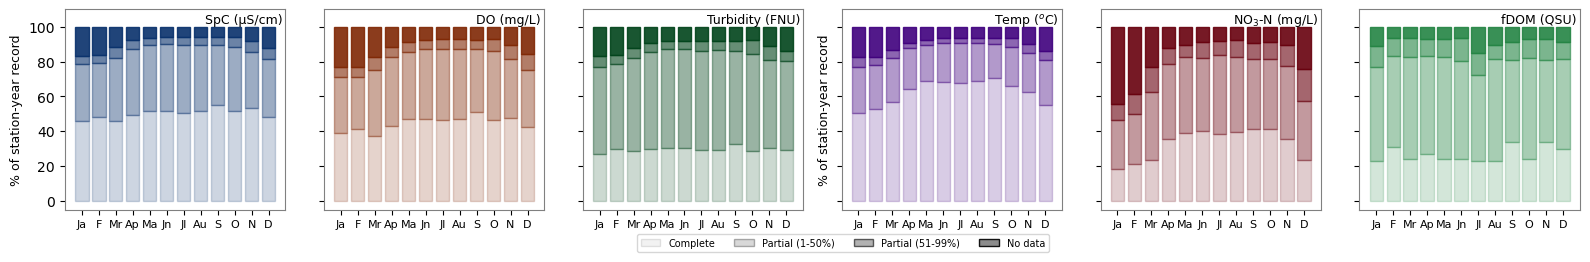

In [156]:
# What is the distribution of records gaps per month per solute?
month_labels = ['Ja','F','Mr','Ap','Ma','Jn','Jl','Au','S','O','N','D']
fig, axes_ij = plt.subplots(1, 6, figsize=(16, 2.5), sharey=True)
axes = axes_ij.flat

for i, solute in enumerate(solutes):
    temp_data_p = monthly_summary[monthly_summary['parameter'] == solute]
    
    # Categorize each station-year-month
    temp_data_p = temp_data_p.copy()
    
    # Binning the data. lower edge -0.1 so exactly-0 lands in Complete
    temp_data_p['category'] = pd.cut(
        temp_data_p['pct_missing'], 
        bins=[-0.1, 0, 50, 99.999, 100], # percent missing
        labels=['Complete', 'Partial (1-50%)', 'Partial (51-99%)', 'No data']
    )

    # For each station-year, count the frequency of each bin per month.
    counts = temp_data_p.groupby(['month', 'category'], observed=False).size().unstack(fill_value=0)
    fractions = counts.div(counts.sum(axis=1), axis=0) * 100
        
    # Create color gradient: darkest for "no data", lightest for "complete"
    edge = PARAM_COLORS[solute]['edge'] 
    colors = [edge, edge, edge, edge]
    alphas = [0.2, 0.4, 0.6, 0.9]

    # Creating a stacked bar plot by addding the bins cumulatively.
    bottom = np.zeros(12)
    categories = ['Complete', 'Partial (1-50%)', 'Partial (51-99%)', 'No data']
    for j, cat in enumerate(categories):
        if cat in fractions.columns:
            vals = fractions[cat].values
            axes[i].bar(range(12), vals, bottom=bottom, 
                       color=colors[j], alpha=alphas[j], 
                       edgecolor=edge, linewidth=1)
            bottom += vals

    # Aesthetic properties
    axes[i].set_ylabel('% of station-year record' if i = 0 else '', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0, labelsize=8)
    axes[i].set_xticks(range(12))
    axes[i].set_xticklabels(month_labels)
    axes[i].set_ylim(-5, 110)
    axes[i].text(11.8, 102, solute_pretty[solute], horizontalalignment='right', fontsize=9)

    # Spines
    axes[i].spines['right'].set(visible=True, color='grey')
    axes[i].spines['left'].set(visible=True, color='grey')
    axes[i].spines['top'].set(visible=True, color='grey')
    axes[i].spines['bottom'].set(visible=True, color='grey')
    
# Add legend
legend_elements = [
    Patch(facecolor='grey', alpha=0.1, edgecolor='black', label='Complete'),
    Patch(facecolor='grey', alpha=0.3, edgecolor='black', label='Partial (1-50%)'),
    Patch(facecolor='grey', alpha=0.6, edgecolor='black', label='Partial (51-99%)'),
    Patch(facecolor='grey', alpha=0.9, edgecolor='black', label='No data'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=7, 
           bbox_to_anchor=(0.53, -0.05))

fig.tight_layout()
plt.savefig(f'../OUTPUT/temporal_patterns/monthly_station_year_record_completeness_distribution.png', dpi=600, bbox_inches='tight')

### The relationship between mean annual temperature and gaps

In [99]:
# Reading and filtering 
basinatlas = pd.read_csv(basin_atlas_filepath+"static_catchment_characteristics.csv")
basinatlas = basinatlas[['STREAM_ID',
                         'tmp_dc_syr', # mean annual temperature
                        ]]

param_dict = {'tmp_dc_syr':'MAT'}

# Converting to true values
basinatlas['tmp_dc_syr'] = basinatlas['tmp_dc_syr']/10

# merging MAT with temporal variables
temperature_data = pd.merge(temporal_summary_long, basinatlas, on='STREAM_ID', how='left')
monthly_temperature_summary = pd.merge(monthly_summary, basinatlas, on='STREAM_ID', how='left')

temperature_data.head()

,STREAM_ID,parameter,pct_missing,length_hr,longest_hr,actual_hr,pct_missing_01,pct_missing_02,pct_missing_03,pct_missing_04,pct_missing_05,pct_missing_06,pct_missing_07,pct_missing_08,pct_missing_09,pct_missing_10,pct_missing_11,pct_missing_12,tmp_dc_syr
0,STREAM-gauge-100,SpC_uScm,1.87,8760.0,4702.0,8596.0,4.44,0.00,0.00,0.00,0.00,3.19,0.00,0.00,0.00,0.00,0.00,14.52,14.875284
1,STREAM-gauge-1010,SpC_uScm,14.02,3609.0,1674.0,3103.0,100.00,100.00,100.00,100.00,0.00,0.00,48.66,3.63,16.25,0.00,100.00,100.00,7.497487
2,STREAM-gauge-1011,SpC_uScm,0.00,4472.0,4472.0,4472.0,100.00,100.00,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,6.867171
3,STREAM-gauge-1018,SpC_uScm,7.83,160001.0,2279.0,147480.0,0.87,0.36,0.40,0.28,0.13,0.28,0.34,1.28,0.56,0.27,0.42,0.27,4.488488
4,STREAM-gauge-102,SpC_uScm,49.60,10541.0,2619.0,5313.0,100.00,100.00,68.82,33.47,70.97,0.00,0.00,0.00,60.83,47.92,32.85,60.98,14.898819


In [203]:
monthly_temperature_summary.head()

,STREAM_ID,parameter,year,month,pct_missing,tmp_dc_syr
0,STREAM-gauge-1,DO_mgL,2014,12,0.0,17.902571
1,STREAM-gauge-1,DO_mgL,2015,1,0.0,17.902571
2,STREAM-gauge-1,DO_mgL,2015,2,0.0,17.902571
3,STREAM-gauge-1,DO_mgL,2015,3,0.0,17.902571
4,STREAM-gauge-1,DO_mgL,2015,4,0.0,17.902571


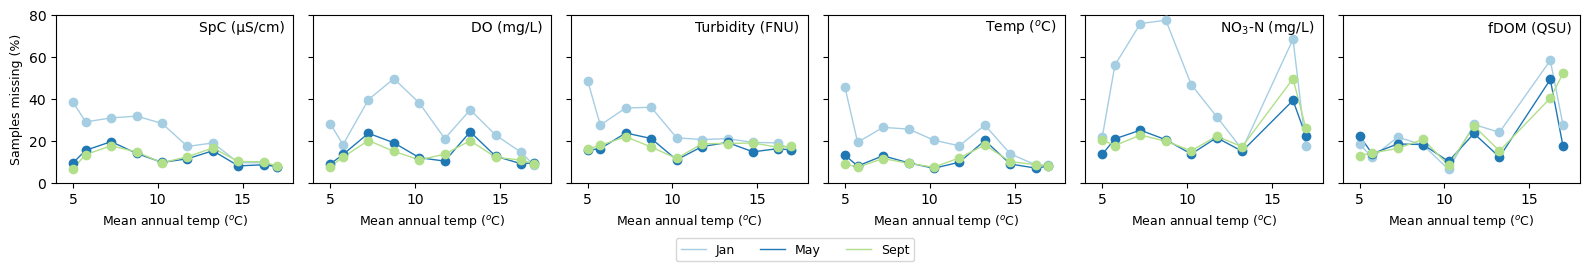

In [226]:
# Setting the months that will be plotted
months = {1: 'Jan', 5: 'May', 8: 'Sept'}
colors = {'Jan': '#a6cee3', 'May': '#1f78b4', 'Sept': '#b2df8a', 'Oct': '#33a02c'}

lower_bound = 5
upper_bound = 17

# setting up the bins (1.5 increments), where the tails get grouped together before of low data density.
# first bin catches (-inf to 5 degrees], and the last catches (20 to inf]
temp_bins = np.concatenate([[-np.inf], np.arange(lower_bound, upper_bound + 1.5, 1.5), [np.inf]])

def binned_stats(x, y, bins, min_n=10):
    d = pd.DataFrame({'x': x, 'y': y})
    d['bin'] = pd.cut(d['x'], bins)

    # This just establishes where on the x axis the point will be plotted. It will take the mid value of the two bin edges, unless it's 
    # the end groups which will just plot on the edges of the bin (5 and 20). 
    # The groupby takes the mean, standard error, and count of the pct_missing for each bin.
    # So the y-axis of what is being plotted is the mean percent of hours missing for month X for Y temperature bin.
    g = d.groupby('bin', observed=False)['y'].agg(['mean', 'sem', 'count'])
    centers = []
    for iv in g.index:
        if iv.left == -np.inf:
            centers.append(lower_bound)      # sit it just left of the first real bin
        elif iv.right == np.inf:
            centers.append(upper_bound)     # just right of the last
        else:
            centers.append(iv.mid)
    g['center'] = centers
    return g[g['count'] >= min_n]

# Plotting the figure
fig, axes = plt.subplots(1, 6, figsize=(16, 2.5), sharey=True)
axes = axes.flat

# For each solute gets binned using the function above. 
for i, solute in enumerate(solutes):
    temp_data_p = monthly_temperature_summary[monthly_temperature_summary['parameter'] == solute]

    for month_num, label in months.items():
        md = temp_data_p[temp_data_p['month'] == month_num]
        s = binned_stats(md['tmp_dc_syr'].values, md['pct_missing'].values, temp_bins)

        # Line traces the trend; marker size shows how many station-years back each bin
        axes[i].plot(s['center'], s['mean'], '-', color=colors[label], lw=1, label=label)
        axes[i].scatter(s['center'], s['mean'],
                        #s=s['count'] / s['count'].max() * 40,
                        color=colors[label], zorder=3)

    # Aesthetic parameters
    axes[i].set_xlim(lower_bound - 1, upper_bound + 1)
    axes[i].set_ylim(0, 80)
    axes[i].text(17.5, 72,  solute_pretty[solute], horizontalalignment='right')
    axes[i].set_ylabel('Samples missing (%)' if i == 0 else '', fontsize=9)
    axes[i].set_xlabel('Mean annual temp ($^{o}$C)', fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()

# Legend for the lines
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.05),
           ncol=len(labels),
           fontsize=9)

fig.tight_layout()
plt.savefig('../OUTPUT/temporal_patterns/record_missing_monthly_MAT.png',
            dpi=600, bbox_inches='tight')